# Differential Abundance

Which cell populations change in frequency between two conditions?

There are two ways to answer that, and this tutorial runs both:

1. **Count cells per cluster.** The classical answer, and the question most people
   actually arrive with — *"are naive B cells rarer in old mice?"* You annotate cells,
   count them per sample, and compare the proportions across conditions. Simple,
   interpretable, and entirely dependent on the annotation you chose.
2. **Score every cell state (Kompot).** `kompot.da` estimates the cell-state *density*
   of each condition over a continuous representation and reports a per-cell log fold
   change with calibrated significance. It says whether any cell **states** are more or
   less common in one condition — **regardless of the annotation**. No clusters required.

The two are complementary: the count gives you a familiar per-cell-type number, Kompot
tells you where on the manifold the shift actually lives — including inside a cluster
whose net count did not move. We do the count first, then Kompot, then compare them.

The method is described in the [paper](https://www.biorxiv.org/content/10.1101/2025.06.03.657769).
For gene-level changes, see [Getting Started](./01_getting_started.ipynb) (DE).

In [1]:
%matplotlib inline

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import palantir
import pandas as pd
import scanpy as sc
from scipy import stats

import kompot

# Consistent, clean plotting style across the tutorial set
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = False
plt.rcParams["image.cmap"] = "Spectral_r"

In [2]:
DATA_PATH = "../data/murine_bone_marrow_aging.h5ad"
GROUPING_COLUMN = "Age"                       # condition column in adata.obs
CONDITIONS = ["Young", "Old"]                 # first entry is the reference
CELL_TYPE_COLUMN = "highres_celltype"         # fine annotation
COARSE_CELL_TYPE_COLUMN = "midres_celltype"   # coarser annotation of the same cells
SAMPLE_COLUMN = "Replicate"                   # biological replicate (mouse)
LIBRARY_COLUMN = "Sample"                     # one sorted library = compartment x mouse
COMPARTMENT_COLUMN = "Compartment"            # FACS gate: HSPC or Mature
DIMENSIONALITY_REDUCTION = "DM_EigenVectors"  # cell-state representation

MIN_CELLS = 50  # ignore cell types too rare to count reliably

## Load Data

In [3]:
import os
from pathlib import Path

import requests
from tqdm.auto import tqdm

Path(DATA_PATH).parent.mkdir(parents=True, exist_ok=True)

if not os.path.exists(DATA_PATH):
    print("Downloading dataset (~2.4 GB) from Zenodo ...")
    url = "https://zenodo.org/records/15587768/files/murine_bone_marrow_aging.h5ad?download=1"
    response = requests.get(url, stream=True)
    total = int(response.headers.get("content-length", 0))
    with open(DATA_PATH, "wb") as file, tqdm(total=total, unit="B", unit_scale=True) as bar:
        for chunk in response.iter_content(chunk_size=1 << 20):
            file.write(chunk)
            bar.update(len(chunk))

adata = ad.read_h5ad(DATA_PATH)
palantir.utils.run_diffusion_maps(adata, pca_key="X_pca_harmony", n_components=40)
adata

AnnData object with n_obs × n_vars = 8090 × 16285
    obs: 'Compartment', 'Replicate', 'Age', 'Sample', 'Info', 'batch', 'doublet_score', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_hb', 'pct_counts_hb', 'S_score', 'G2M_score', 'phase', 'leiden', 'phenograph', 'highres_celltype', 'midres_celltype'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'hb', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'Age_colors', 'Compartment_colors', 'DMEigenValues', 'DM_EigenValues', 'Info_colors', 'README', 'Replicate_colors', 'Sample_colors', 'batch_colors', 'draw_graph', 'highres_celltype_colors', 'hvg', 'leiden', 'leiden_colors', 'midres_celltype_colors', 'neighbors', 'pca', 'phase_colors', 'umap'
    obsm: 'AbCapture', 'DM_EigenVectors', 'HTO', 'X_draw_graph_fa', 'X_pca', 'X_pca_harmony', 'X_

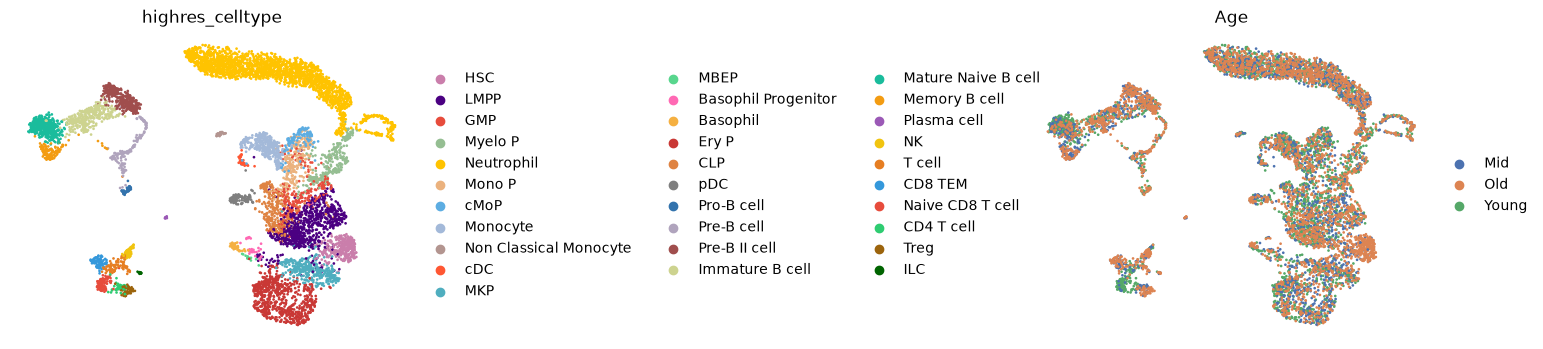

In [4]:
sc.pl.umap(adata, color=[CELL_TYPE_COLUMN, GROUPING_COLUMN], frameon=False, wspace=1.3)

## 1. Counting cells per cluster

The familiar analysis: count how many cells of each annotated type each animal
contributes, turn the counts into within-sample proportions, and compare Young against
Old across replicates.

One detail decides whether the numbers mean anything. Cells here were **FACS-sorted into
two compartments** before sequencing (`Compartment`: `HSPC` and `Mature`), so each mouse
yields two libraries and the HSPC : Mature ratio is set by the sorting gate, not by the
animal. Proportions are therefore only comparable **within a compartment**. Every cell
type in this dataset sits ≥91% inside one compartment, so we score each type against the
libraries of its own compartment — three Young mice versus three Old mice.

In [5]:
obs = adata.obs[adata.obs[GROUPING_COLUMN].isin(CONDITIONS)]

# Which compartment does each cell type live in, and how many cells do we have?
by_compartment = pd.crosstab(obs[CELL_TYPE_COLUMN], obs[COMPARTMENT_COLUMN])
home = by_compartment.idxmax(axis=1)                     # majority compartment per type
keep = by_compartment.sum(axis=1) >= MIN_CELLS

# Composition of every library: what fraction of it is cell type X?
counts = pd.crosstab(obs[LIBRARY_COLUMN], obs[CELL_TYPE_COLUMN])
props = counts.div(counts.sum(axis=1), axis=0) * 100     # percent of library

library = obs.groupby(LIBRARY_COLUMN, observed=True)[
    [GROUPING_COLUMN, COMPARTMENT_COLUMN]
].agg(lambda s: s.iloc[0])

props.head()

highres_celltype,HSC,LMPP,GMP,Myelo P,Neutrophil,Mono P,cMoP,Monocyte,Non Classical Monocyte,cDC,...,Mature Naive B cell,Memory B cell,Plasma cell,NK,T cell,CD8 TEM,Naive CD8 T cell,CD4 T cell,Treg,ILC
Sample,,,,,,,,,,,,,,,,,,,,,
HSPC_Old_1,23.310023,23.076923,6.293706,8.857809,0.0,8.857809,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HSPC_Old_2,15.887850,26.635514,6.074766,8.411215,0.0,8.411215,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HSPC_Old_3,16.222760,26.392252,7.021792,8.232446,0.0,6.779661,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HSPC_Young_1,0.931677,22.360248,7.763975,8.695652,0.0,18.012422,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HSPC_Young_2,0.266667,28.533333,6.933333,10.400000,0.0,7.466667,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
def count_test(cell_types, home, props, library):
    """Young vs. Old proportion per cell type, within that type's own compartment."""
    ref, alt = CONDITIONS
    rows = {}
    for ct in cell_types:
        same_gate = library[COMPARTMENT_COLUMN] == home[ct]
        y = props.loc[same_gate & (library[GROUPING_COLUMN] == ref), ct].values
        o = props.loc[same_gate & (library[GROUPING_COLUMN] == alt), ct].values
        rows[ct] = {
            f"{ref}_%": y.mean(),
            f"{alt}_%": o.mean(),
            "log2FC": np.log2((o.mean() + 1e-3) / (y.mean() + 1e-3)),
            "p": stats.ttest_ind(o, y, equal_var=False).pvalue,   # Welch, n = 3 vs 3
        }
    return pd.DataFrame(rows).T.sort_values("log2FC")


counted = count_test(by_compartment.index[keep], home, props, library)
counted.round(3)

,Young_%,Old_%,log2FC,p
Naive CD8 T cell,4.962,0.053,-6.520,0.082
Mature Naive B cell,14.758,3.626,-2.025,0.039
CLP,13.053,7.192,-0.860,0.031
cMoP,2.921,1.623,-0.847,0.230
Ery P,23.337,15.522,-0.588,0.012
Monocyte,9.096,6.296,-0.531,0.241
Mono P,11.406,8.016,-0.509,0.416
GMP,7.555,6.463,-0.225,0.063
Myelo P,9.621,8.500,-0.179,0.141
T cell,1.870,1.736,-0.107,0.737


significant cell types: 5 of 20


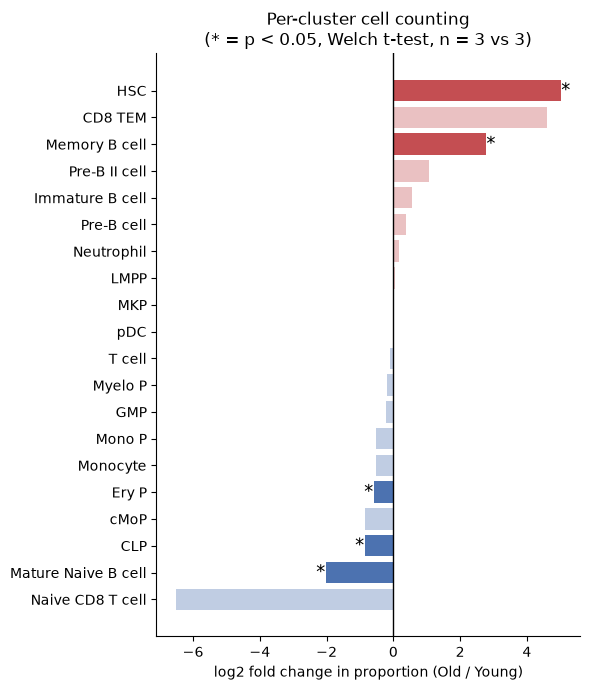

In [7]:
from matplotlib.colors import to_rgba

sig = counted["p"] < 0.05
# solid = significant, faded = not; red = enriched in Old, blue = depleted
bar_colors = [to_rgba("#C44E52" if f > 0 else "#4C72B0", 1.0 if s else 0.35)
              for f, s in zip(counted["log2FC"], sig)]

fig, ax = plt.subplots(figsize=(6, 7))
ax.barh(counted.index, counted["log2FC"], color=bar_colors)
for y, (ct, row) in enumerate(counted.iterrows()):
    if sig[ct]:
        ax.text(row["log2FC"] + np.sign(row["log2FC"]) * 0.15, y, "*",
                va="center", ha="center", fontsize=13)
ax.axvline(0, color="k", lw=1)
ax.set(xlabel=f"log2 fold change in proportion ({CONDITIONS[1]} / {CONDITIONS[0]})",
       title="Per-cluster cell counting\n(* = p < 0.05, Welch t-test, n = 3 vs 3)")
plt.tight_layout()

print(f"significant cell types: {int(sig.sum())} of {len(counted)}")

The classic aging phenotype falls straight out: **HSCs expand** sharply in old marrow
(log2FC +5.0) and **memory B cells** rise, while the **naive lymphoid compartment shrinks**
(mature naive B cells, CLPs) — as do erythroid progenitors.

Now read the `p` column, because that is where the count starts costing you:

- **Only 5 of 20 cell types clear `p < 0.05`, and the *largest* effect in the table is not one
  of them.** Naive CD8 T cells fall from 5.0% of the mature compartment to 0.05% — a ~90-fold
  depletion — at `p = 0.08`, and CD8 TEM cells rise ~25-fold at `p = 0.07`. (The second-largest
  effect, HSC, does clear it, at `p = 0.02`.) A per-cluster proportion crushes every cell into a
  single number per animal, so with three mice per condition even enormous effects can miss.
- **The answer is only as good as the annotation.** Change the clustering resolution and
  you change the result — as we are about to demonstrate.
- **It says nothing about *where inside* a cluster the change happened.**

## 2. Differential abundance without clusters

`kompot.da` never sees the labels. It estimates the cell-state density of each condition
over `DM_EigenVectors` and scores **every cell**.
See [`kompot.da`](https://kompot.readthedocs.io/en/latest/simplified.html#kompot.da).

In [8]:
da_results = kompot.da(
    adata,
    groupby=GROUPING_COLUMN,
    condition1=CONDITIONS[0],
    condition2=CONDITIONS[1],
    obsm_key=DIMENSIONALITY_REDUCTION,
)

[2026-07-11 23:12:20,388] [INFO    ] Condition 1 (Young): 2,917 cells


[2026-07-11 23:12:20,390] [INFO    ] Condition 2 (Old): 3,116 cells


[2026-07-11 23:12:20,399] [INFO    ] Fitting density estimator for condition 1...


[2026-07-11 23:13:17,059] [INFO    ] Fitting density estimator for condition 2...


[2026-07-11 23:14:03,696] [INFO    ] This run will have `run_id=0`.


Per-cell results land in `adata.obs`:

- `kompot_da_Young_to_Old_lfc` — log fold change (positive = enriched in Old)
- `kompot_da_Young_to_Old_lfc_direction` — up / down / unchanged

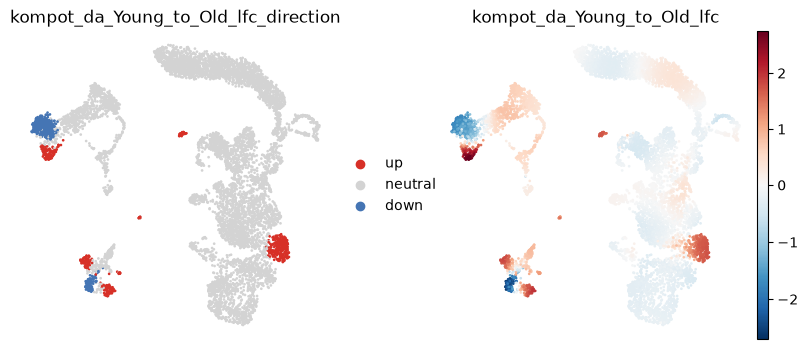

In [9]:
c1, c2 = CONDITIONS
direction = f"kompot_da_{c1}_to_{c2}_lfc_direction"
lfc = f"kompot_da_{c1}_to_{c2}_lfc"

sc.pl.embedding(
    adata, "umap",
    color=[direction, lfc],
    color_map="RdBu_r", vcenter=0, frameon=False,
)

### Volcano plot

Effect size vs. significance, one point per cell ([`volcano_da`](https://kompot.readthedocs.io/en/latest/plotting.html#kompot.plot.volcano_da)):

[2026-07-11 23:14:04,055] [INFO    ] Found DA run info for run_id=-1


[2026-07-11 23:14:04,056] [INFO    ] Found lfc_key='kompot_da_Young_to_Old_lfc' from run info


[2026-07-11 23:14:04,056] [INFO    ] Found ptp_key='kompot_da_Young_to_Old_neg_log10_lfc_ptp' from run info


[2026-07-11 23:14:04,057] [INFO    ] Successfully inferred fields: {'lfc_key': 'kompot_da_Young_to_Old_lfc', 'ptp_key': 'kompot_da_Young_to_Old_neg_log10_lfc_ptp'}


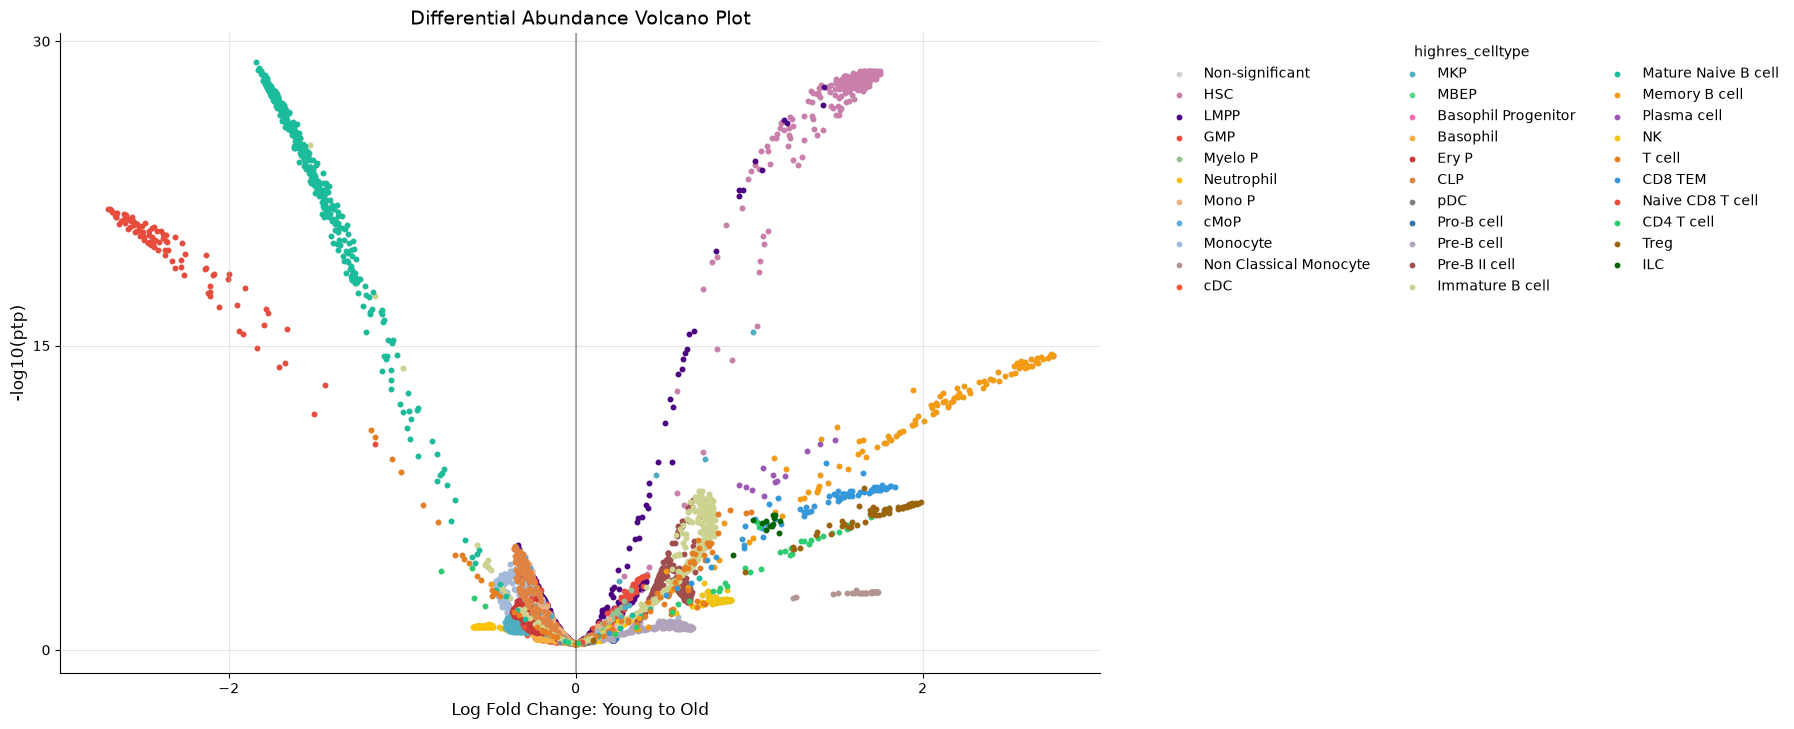

In [10]:
kompot.plot.volcano_da(adata, color=CELL_TYPE_COLUMN)

Show only the significantly changed cells, split into enriched vs. depleted with `mgroups`
([`kompot.plot.embedding`](https://kompot.readthedocs.io/en/latest/plotting.html#kompot.plot.embedding)):

[2026-07-11 23:14:05,095] [INFO    ] Selected 585 cells out of 8,090 total cells.


[2026-07-11 23:14:05,190] [INFO    ] Selected 490 cells out of 8,090 total cells.


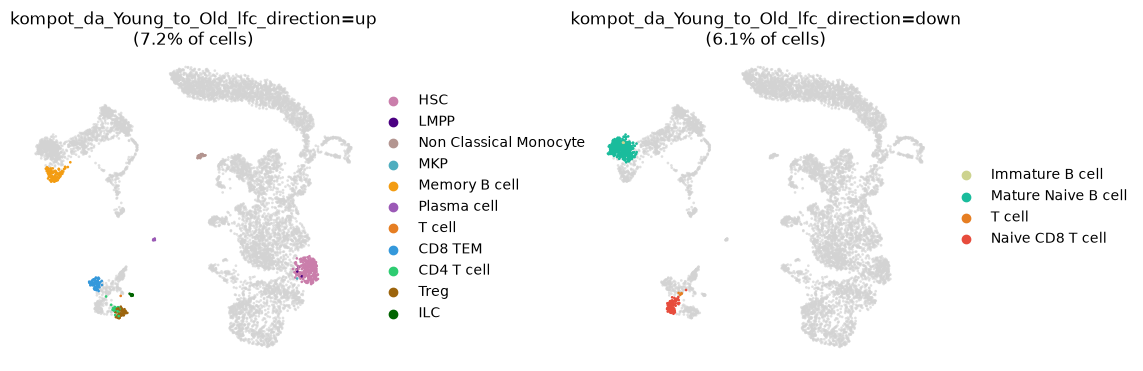

In [11]:
kompot.plot.embedding(
    adata, "umap",
    color=CELL_TYPE_COLUMN,
    mgroups=[{direction: [d]} for d in ["up", "down"]],
    frameon=False, wspace=.5,
)

### Summary by cell type

The per-cell calls can of course still be *summarized* over an annotation — that is a
read-out, not an input ([`direction_barplot`](https://kompot.readthedocs.io/en/latest/plotting.html#kompot.plot.direction_barplot)):

[2026-07-11 23:14:05,838] [INFO    ] Found DA run info for run_id=-1


[2026-07-11 23:14:05,839] [INFO    ] Found direction_key='kompot_da_Young_to_Old_lfc_direction' from run info


[2026-07-11 23:14:05,840] [INFO    ] Successfully inferred fields: {'direction_key': 'kompot_da_Young_to_Old_lfc_direction'}


[2026-07-11 23:14:05,840] [INFO    ] Using DA run 0 for direction_barplot: comparing Young to Old


[2026-07-11 23:14:05,841] [INFO    ] Creating direction barplot: comparing Young to Old


[2026-07-11 23:14:05,841] [INFO    ] Using fields - category_column: 'highres_celltype', direction_column: 'kompot_da_Young_to_Old_lfc_direction'


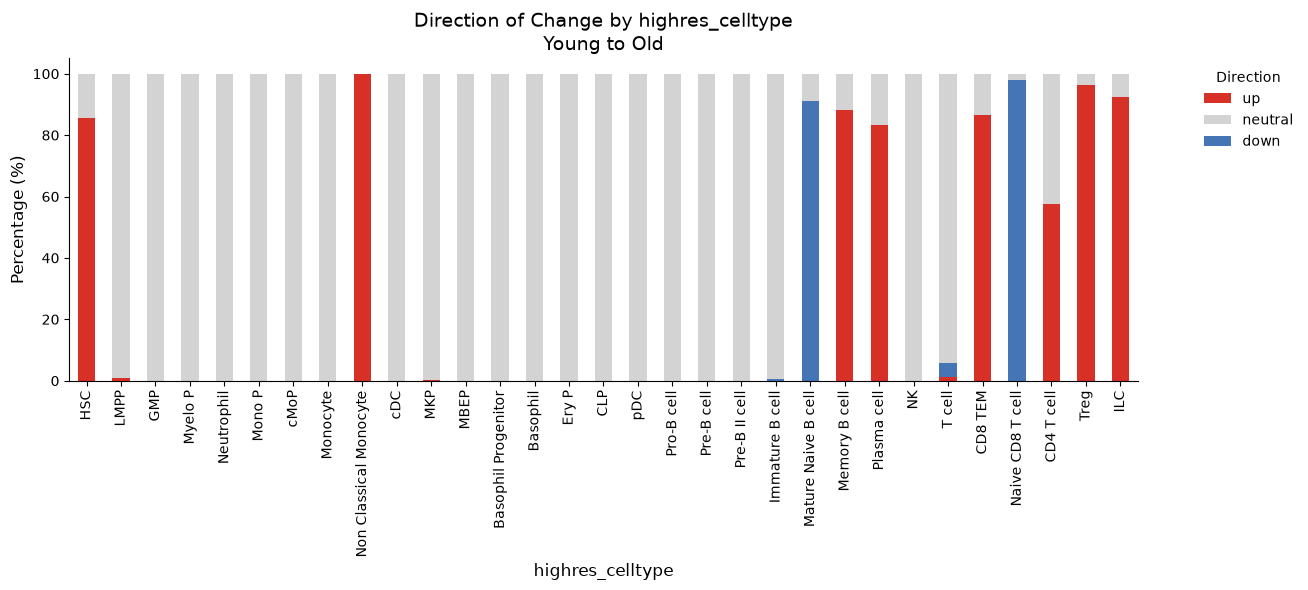

In [12]:
kompot.plot.direction_barplot(adata, category_column=CELL_TYPE_COLUMN)

## 3. Do the two answers agree?

They should — and they do. Averaging Kompot's per-cell log fold change within each
annotated cluster reproduces the counting result almost exactly, **without Kompot ever
being given the labels**:

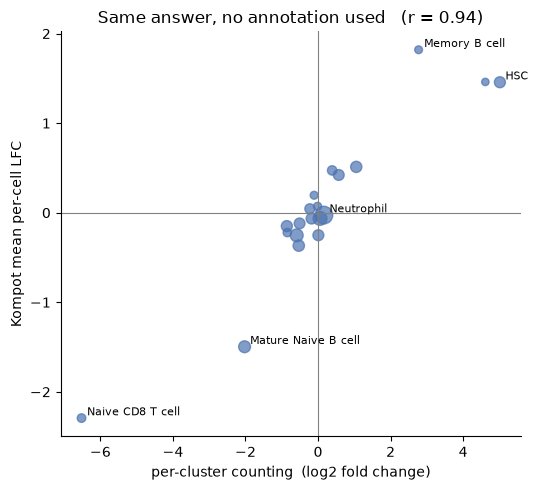

In [13]:
yo = adata.obs[adata.obs[GROUPING_COLUMN].isin(CONDITIONS)]
per_type = yo.groupby(CELL_TYPE_COLUMN, observed=True).agg(
    n=(lfc, "size"), kompot_mean_lfc=(lfc, "mean"),
)
merged = counted.join(per_type).dropna()
r = merged["log2FC"].corr(merged["kompot_mean_lfc"])

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.scatter(merged["log2FC"], merged["kompot_mean_lfc"],
           s=np.sqrt(merged["n"]) * 4, alpha=0.7, color="#4C72B0")
for ct in ["HSC", "Naive CD8 T cell", "Mature Naive B cell", "Memory B cell", "Neutrophil"]:
    if ct in merged.index:
        ax.annotate(ct, (merged.loc[ct, "log2FC"], merged.loc[ct, "kompot_mean_lfc"]),
                    fontsize=8, xytext=(4, 2), textcoords="offset points")
ax.axhline(0, color="grey", lw=.8)
ax.axvline(0, color="grey", lw=.8)
ax.set(xlabel="per-cluster counting  (log2 fold change)",
       ylabel="Kompot mean per-cell LFC",
       title=f"Same answer, no annotation used   (r = {r:.2f})")
plt.tight_layout()

## 4. Where the cluster count goes blind

The counting answer is *inherited from the annotation*. Re-run exactly the same count on a
**coarser** annotation of the very same cells (`midres_celltype`, which merges the fine
labels into broader lineages) and watch what happens to the populations whose subsets move
in opposite directions.

In [14]:
obs_c = adata.obs[adata.obs[GROUPING_COLUMN].isin(CONDITIONS)]
by_comp_c = pd.crosstab(obs_c[COARSE_CELL_TYPE_COLUMN], obs_c[COMPARTMENT_COLUMN])
home_c = by_comp_c.idxmax(axis=1)
keep_c = by_comp_c.sum(axis=1) >= MIN_CELLS

counts_c = pd.crosstab(obs_c[LIBRARY_COLUMN], obs_c[COARSE_CELL_TYPE_COLUMN])
props_c = counts_c.div(counts_c.sum(axis=1), axis=0) * 100

coarse = count_test(by_comp_c.index[keep_c], home_c, props_c, library)

# What does Kompot say about the cells inside each coarse cluster?
g = obs_c.groupby(COARSE_CELL_TYPE_COLUMN, observed=True)
coarse["n"] = g.size()
coarse["kompot_%_up"] = g[direction].apply(lambda s: (s == "up").mean()) * 100
coarse["kompot_%_down"] = g[direction].apply(lambda s: (s == "down").mean()) * 100

coarse.sort_values("kompot_%_down", ascending=False).round(3).head(8)

,Young_%,Old_%,log2FC,p,n,kompot_%_up,kompot_%_down
Mature B cell,15.188,6.945,-1.129,0.068,404,14.356,76.733
T cell,7.646,4.905,-0.640,0.291,230,22.609,40.435
Immature B cell,5.112,7.595,0.571,0.150,234,0.000,0.427
Ery P,23.337,15.522,-0.588,0.012,466,0.000,0.000
Monocyte,9.876,6.721,-0.555,0.171,303,7.261,0.000
Mono P,11.406,8.016,-0.509,0.416,310,0.000,0.000
CLP,13.053,7.192,-0.860,0.031,253,0.000,0.000
Myelo P,9.621,8.500,-0.179,0.141,234,0.000,0.000


Look at **`T cell`**. The count calls it unchanged (log2FC −0.64, `p = 0.29`) — yet Kompot
finds **23% of its cells enriched and 40% depleted**. A cluster holding both an emptying and
an expanding cell state nets out to roughly nothing once you reduce it to a single proportion.

**`Mature B cell`** is the milder version of the same failure: the count sees a depletion
(log2FC −1.13) that misses significance at `p = 0.07`, while Kompot resolves 77% of the
cluster as depleted *and* a 14% subpopulation as enriched — two opposing programs averaged
into one blunt number.

Neither count is *wrong*. Each is answering a coarser question than the one you asked.

Zoom into the coarse `T cell` cluster and cross-tabulate Kompot's per-cell calls against the
fine labels it was never given:

counting:  log2FC = -0.64,  p = 0.29  ->  no significant change
kompot:    23% of cells up, 40% of cells down

Kompot's calls vs. the fine labels it never saw (n = 230):
kompot_da_Young_to_Old_lfc_direction  up  neutral  down
highres_celltype                                       
T cell                                 1       62     3
CD8 TEM                               43        7     0
Naive CD8 T cell                       0        2    90
CD4 T cell                             8       14     0


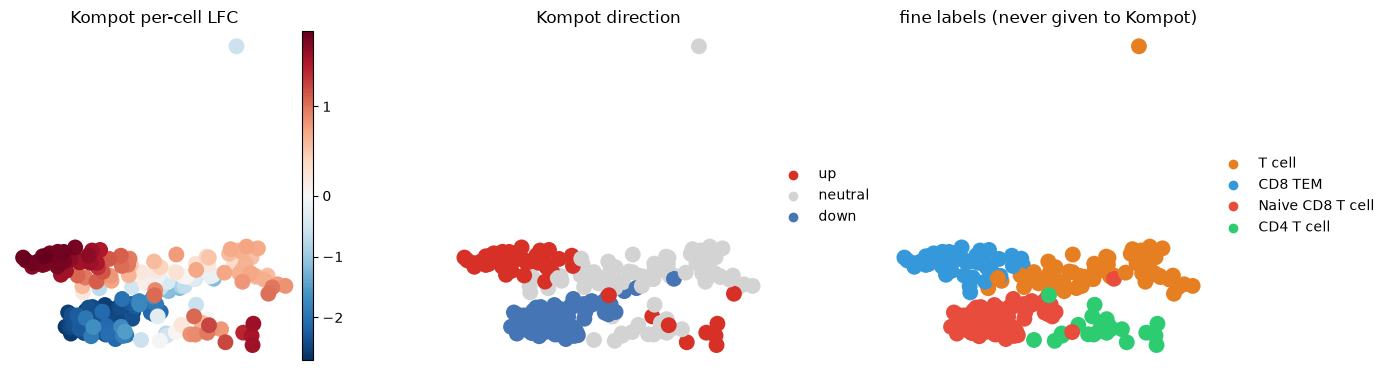

In [15]:
COARSE_GROUP = "T cell"
# Young/Old only, so this zoom counts the same cells as the tables above.
sub = adata[
    (adata.obs[COARSE_CELL_TYPE_COLUMN] == COARSE_GROUP)
    & (adata.obs[GROUPING_COLUMN].isin(CONDITIONS))
].copy()

row = coarse.loc[COARSE_GROUP]
print(f"counting:  log2FC = {row['log2FC']:+.2f},  p = {row['p']:.2f}  ->  no significant change")
print(f"kompot:    {row['kompot_%_up']:.0f}% of cells up, {row['kompot_%_down']:.0f}% of cells down")

# Which fine subsets is Kompot actually calling up and down?
breakdown = pd.crosstab(sub.obs[CELL_TYPE_COLUMN], sub.obs[direction])
breakdown = breakdown.loc[breakdown.sum(axis=1) > 0]
print(f"\nKompot's calls vs. the fine labels it never saw (n = {sub.n_obs}):")
print(breakdown.to_string())

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
sc.pl.embedding(sub, "umap", color=lfc, cmap="RdBu_r", vcenter=0, ax=axes[0],
                show=False, frameon=False, title="Kompot per-cell LFC")
sc.pl.embedding(sub, "umap", color=direction, ax=axes[1],
                show=False, frameon=False, title="Kompot direction")
sc.pl.embedding(sub, "umap", color=CELL_TYPE_COLUMN, ax=axes[2],
                show=False, frameon=False, title="fine labels (never given to Kompot)")
plt.tight_layout()

The cross-tabulation is unambiguous. Kompot's **depleted** calls are the **naive** T
compartment — 90 of the 93 down-cells are `Naive CD8 T cell`, and 98% of that subset is called
down. Its **enriched** calls are the **memory / effector** compartment — 86% of `CD8 TEM` is
called up, and not one is called down. Kompot drew the naive/memory boundary from the
cell-state geometry alone.

On the fine annotation the count finds this too (naive CD8 T −6.5, CD8 TEM +4.6) — but only
*because* someone had already drawn that boundary for it. That is the whole point: **Kompot's
answer does not depend on the annotation being right.**

Practical reading: use the per-cluster count when you have a trusted annotation and want a
familiar per-cell-type number; use `kompot.da` to find the shifts, at whatever resolution
they happen to live, before committing to labels.

## 5. Accounting for sample variance

With biological replicates, add `sample_col` so the test reflects between-animal variation
— the same concern that motivates the replicate-level t-test in the counting section, now
applied per cell. The test becomes more conservative, so we relax the threshold slightly.
This adds a `_sample_var` set of results as `run_id=1`:

In [16]:
da_sample_var = kompot.da(
    adata,
    groupby=GROUPING_COLUMN,
    condition1=c1, condition2=c2,
    obsm_key=DIMENSIONALITY_REDUCTION,
    sample_col=SAMPLE_COLUMN,
    threshold=kompot.DAThresholdSettings(ptp_threshold=0.1),  # relaxed from 0.05
)

[2026-07-11 23:14:07,676] [INFO    ] Results with result_key='kompot_da' already exist in the dataset. Previous run was at 2026-07-11T23:14:03.636291 comparing Young to Old. Fields that will be overwritten: obs.kompot_da_Young_to_Old_lfc, obs.kompot_da_Young_log_density, obs.kompot_da_Old_log_density. Note: Only fields NOT affected by sample variance (like lfc, log_density) will be overwritten since they don't use the sample variance suffix. These results will likely be identical if other parameters haven't changed. This is a partial rerun with sample variance added to a previous analysis with matching parameters. Set overwrite=False to prevent overwriting or overwrite=True to silence this message.


[2026-07-11 23:14:07,678] [INFO    ] Condition 1 (Young): 2,917 cells


[2026-07-11 23:14:07,678] [INFO    ] Condition 2 (Old): 3,116 cells


[2026-07-11 23:14:07,682] [INFO    ] Using sample column 'Replicate' for sample variance estimation


[2026-07-11 23:14:07,684] [INFO    ] Found 3 unique sample(s) in condition 1


...

[2026-07-11 23:15:30,214] [INFO    ] Training estimator for group 2 with 1,019 cells


[2026-07-11 23:15:39,994] [INFO    ] Training estimator for group 3 with 1,040 cells


[2026-07-11 23:15:56,065] [INFO    ] Computing sample-specific variance for condition 1...


[2026-07-11 23:16:00,929] [INFO    ] Computing sample-specific variance for condition 2...


[2026-07-11 23:16:05,447] [INFO    ] This run will have `run_id=1`.


Fold change is unchanged; significance (the z-score) becomes more conservative:

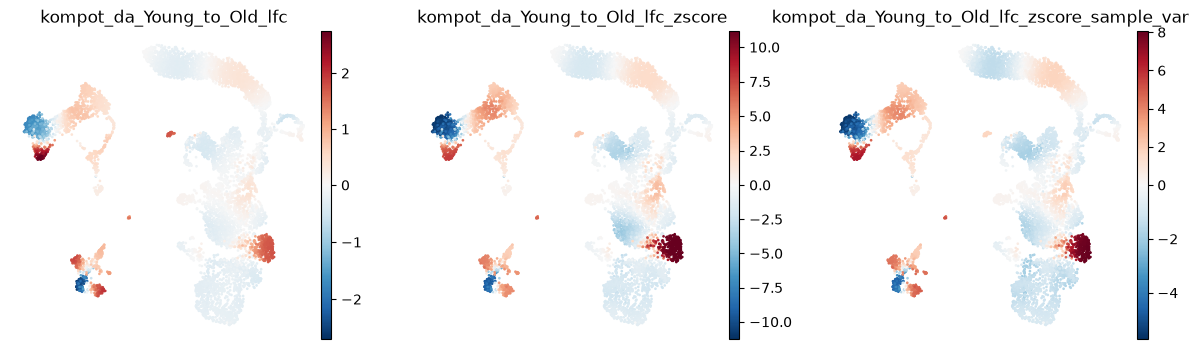

In [17]:
sc.pl.embedding(
    adata, "umap",
    color=[
        f"kompot_da_{c1}_to_{c2}_lfc",
        f"kompot_da_{c1}_to_{c2}_lfc_zscore",
        f"kompot_da_{c1}_to_{c2}_lfc_zscore_sample_var",
    ],
    color_map="RdBu_r", vcenter=0, ncols=3, frameon=False,
)

Volcano plots, standard vs. sample-variance:

[2026-07-11 23:16:06,034] [INFO    ] Found DA run info for run_id=0


[2026-07-11 23:16:06,034] [INFO    ] Found lfc_key='kompot_da_Young_to_Old_lfc' from run info


[2026-07-11 23:16:06,035] [INFO    ] Found ptp_key='kompot_da_Young_to_Old_neg_log10_lfc_ptp' from run info


[2026-07-11 23:16:06,036] [WARNING ] Field 'kompot_da_Young_to_Old_lfc' has been written by 2 different runs, indicating potential overwrites


[2026-07-11 23:16:06,036] [WARNING ] Field 'kompot_da_Young_to_Old_neg_log10_lfc_ptp' was last written by run 0, but current context expects run 1. The field may have been overwritten.


[2026-07-11 23:16:06,037] [INFO    ] Successfully inferred fields: {'lfc_key': 'kompot_da_Young_to_Old_lfc', 'ptp_key': 'kompot_da_Young_to_Old_neg_log10_lfc_ptp'}


[2026-07-11 23:16:06,038] [WARNING ] Field inference completed with 2 warnings


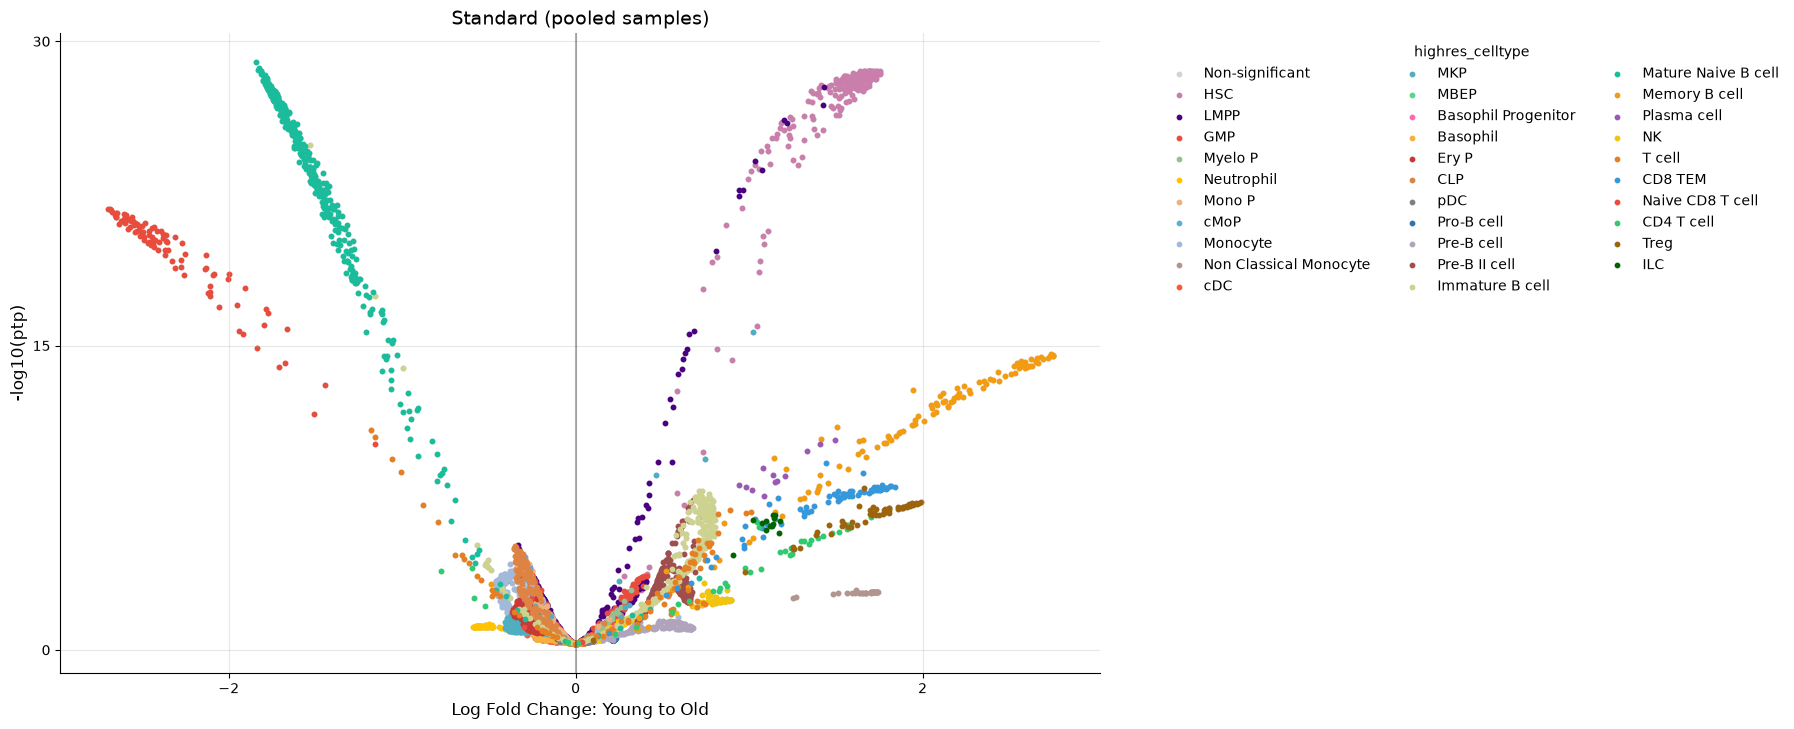

In [18]:
kompot.plot.volcano_da(adata, color=CELL_TYPE_COLUMN, run_id=0, title="Standard (pooled samples)")

[2026-07-11 23:16:07,018] [INFO    ] Found DA run info for run_id=1


[2026-07-11 23:16:07,019] [INFO    ] Found lfc_key='kompot_da_Young_to_Old_lfc' from run info


[2026-07-11 23:16:07,019] [INFO    ] Found ptp_key='kompot_da_Young_to_Old_neg_log10_lfc_ptp_sample_var' from run info


[2026-07-11 23:16:07,020] [WARNING ] Field 'kompot_da_Young_to_Old_lfc' has been written by 2 different runs, indicating potential overwrites


[2026-07-11 23:16:07,021] [INFO    ] Successfully inferred fields: {'lfc_key': 'kompot_da_Young_to_Old_lfc', 'ptp_key': 'kompot_da_Young_to_Old_neg_log10_lfc_ptp_sample_var'}


[2026-07-11 23:16:07,022] [WARNING ] Field inference completed with 1 warnings


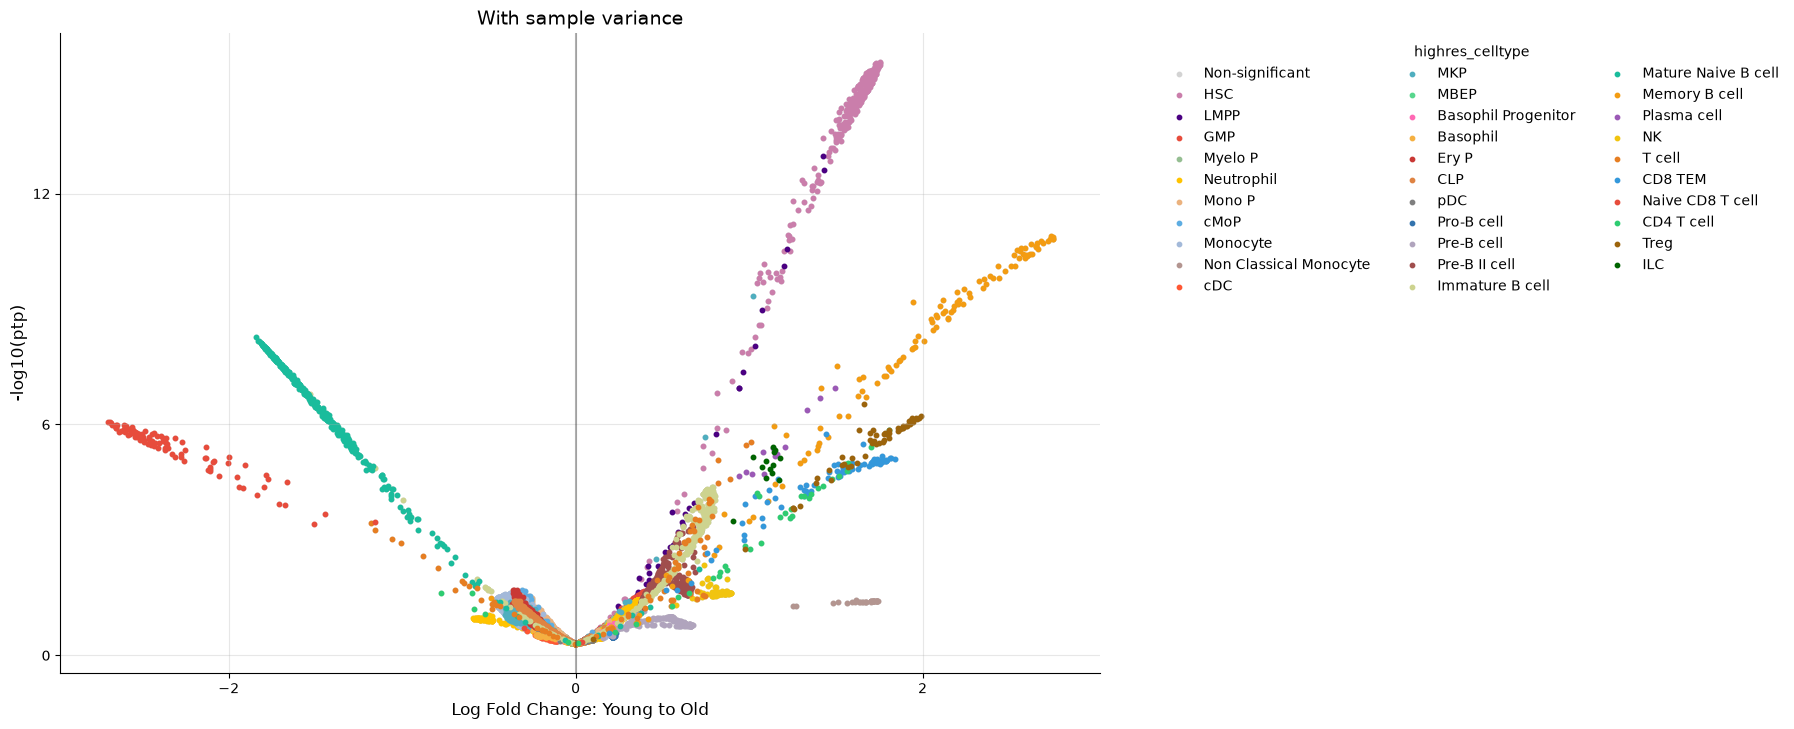

In [19]:
kompot.plot.volcano_da(adata, color=CELL_TYPE_COLUMN, run_id=1, title="With sample variance")

Fewer cells clear significance under sample variance, but effect sizes and the overall
cell-type pattern are preserved — the surviving calls are the robust ones.

In [20]:
kompot.cleanup(adata)
adata.write_h5ad("../data/murine_bone_marrow_aging_da.h5ad")

[2026-07-11 23:16:07,999] [WARNING ] No run history found for de analysis.


## Where to go deeper

- **[Getting Started](./01_getting_started.ipynb)** — differential *expression*.
- **[DE with sample variance](./03_sample_variance.ipynb)** — the gene-level counterpart to the section above.
- **[Smooth expression](./05_smooth_expression.ipynb)** — the GP primitive that underlies both DA and DE.
- **[Paper](https://www.biorxiv.org/content/10.1101/2025.06.03.657769)** ·
  **[Documentation](https://kompot.readthedocs.io)**